# EVALUACIÓN FINAL: ANÁLISIS DE DATOS DE MIGRACIÓN CON NUMPY Y PANDAS

Un instituto de investigación internacional está analizando datos de migración del siglo XXI para identificar tendencias y factores socioeconómicos que afectan los movimientos de población. Se ha entregado un dataset en formato CSV con información sobre migraciones entre distintos países, incluyendo cantidad de migrantes, razones de migración y variables económicas.

El instituto necesita que analices, transformes y prepares los datos para extraer información útil que ayude en la toma de decisiones.

**Objetivo**  
Evaluar la capacidad del estudiante para manejar datos utilizando NumPy y Pandas, aplicando técnicas de limpieza, transformación, agrupamiento y combinación de datos en un contexto realista.


## 1. Limpieza y Transformación de Datos (3 puntos)
- Carga el dataset en un DataFrame de Pandas.  
- Identifica y trata valores perdidos en el dataset.  
- Detecta y filtra *outliers* usando el método del rango intercuartílico (IQR).  
- Reemplaza los valores de la columna `Razon_Migracion` usando mapeo de valores (ejemplo: “Económica” → “Trabajo”, “Conflicto” → “Guerra”).


In [13]:
# Librerias 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
# Carga dataset
df=pd.read_csv("migracion.csv")

df

,Pais_Origen,Pais_Destino,Año,Cantidad_Migrantes,Razon_Migracion,PIB_Origen,PIB_Destino,IDH_Origen,IDH_Destino
0,Venezuela,España,2018,250000,Económica,5000,30000,0.70,0.89
1,Siria,Alemania,2015,800000,Conflicto,2000,45000,0.55,0.94
2,México,EEUU,2020,300000,Económica,9000,65000,0.78,0.92
3,India,Canadá,2019,150000,Educativa,2500,48000,0.65,0.93
4,Bangladesh,Italia,2021,120000,Económica,2000,35000,0.61,0.89
5,Afganistán,Pakistán,2022,500000,Conflicto,1000,5000,0.49,0.60
6,Ucrania,Polonia,2022,700000,Conflicto,13000,18000,0.77,0.85
7,Filipinas,Arabia Saudita,2017,200000,Económica,3200,23000,0.71,0.85
8,Haití,Chile,2019,90000,Económica,1800,15000,0.50,0.85
9,Argentina,España,2021,110000,Económica,10000,30000,0.83,0.89


In [15]:
# Exploración inicial

print(f"Información inicial del data set:")
print({df.info()})
print("\n Dimensiones del DataFrame:", df.shape)
print("\n Primeras 5 filas:")
print(df.head(5))
print("\n Valores nulos:")
print(df.isnull().sum())
print("\n Estadísticas descriptivas:")
print(df.describe())


Información inicial del data set:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Pais_Origen          10 non-null     object 
 1    Pais_Destino        10 non-null     object 
 2    Año                 10 non-null     int64  
 3    Cantidad_Migrantes  10 non-null     int64  
 4    Razon_Migracion     10 non-null     object 
 5    PIB_Origen          10 non-null     int64  
 6    PIB_Destino         10 non-null     int64  
 7    IDH_Origen          10 non-null     float64
 8    IDH_Destino         10 non-null     float64
dtypes: float64(2), int64(4), object(3)
memory usage: 852.0+ bytes
{None}

 Dimensiones del DataFrame: (10, 9)

 Primeras 5 filas:
   Pais_Origen   Pais_Destino     Año    Cantidad_Migrantes   Razon_Migracion  \
0  Venezuela     España           2018               250000   Económica         
1  Siria         Alema

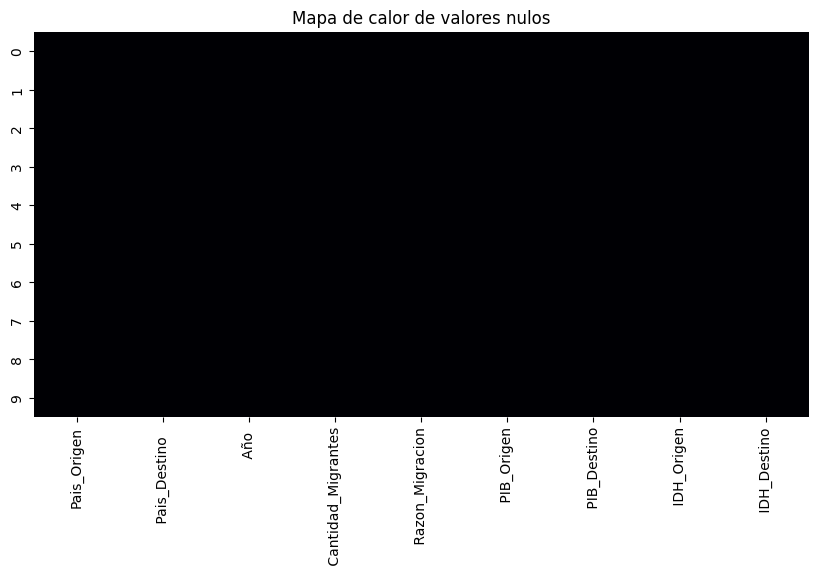

In [16]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='magma', yticklabels=True)
plt.title("Mapa de calor de valores nulos")
plt.show()

In [17]:
# Cambio de nombres de columnas

df.columns=df.columns = df.columns.str.replace(" ", "")
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Pais_Origen         10 non-null     object 
 1   Pais_Destino        10 non-null     object 
 2   Año                 10 non-null     int64  
 3   Cantidad_Migrantes  10 non-null     int64  
 4   Razon_Migracion     10 non-null     object 
 5   PIB_Origen          10 non-null     int64  
 6   PIB_Destino         10 non-null     int64  
 7   IDH_Origen          10 non-null     float64
 8   IDH_Destino         10 non-null     float64
dtypes: float64(2), int64(4), object(3)
memory usage: 852.0+ bytes


In [18]:
# Función de detección y filtro de outliers

def detectar_outliers_iqr(df: pd.DataFrame, columna: str,graficar: bool = True):
    """
    Detecta y filtra outliers en un DataFrame usando el método intercuartílico (IQR).
    
    Parámetros
    ----------
    df : pd.DataFrame
        DataFrame de entrada.
    columna : str
        Nombre de la columna sobre la cual aplicar el método IQR.
    
    Retorna
    -------
    outliers : pd.DataFrame
        Filas que son consideradas outliers.
    df_filtrado : pd.DataFrame
        DataFrame sin outliers.
    limites : dict
        Diccionario con Q1, Q3, IQR, límite inferior y límite superior.
    """
     # Graficar boxplot
    if graficar:
        plt.figure(figsize=(6, 4))
        plt.boxplot(df[columna], vert=False, patch_artist=True,
                    boxprops=dict(facecolor="lightblue", color="blue"),
                    medianprops=dict(color="red", linewidth=2),
                    whiskerprops=dict(color="black"),
                    capprops=dict(color="black"),
                    flierprops=dict(markerfacecolor="orange", marker="o", markersize=8, linestyle="none"))
        plt.title(f"Boxplot de {columna}")
        plt.xlabel(columna)
        plt.show()
    # Calcular cuartiles e IQR
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    # Detectar outliers
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    
    # Filtrar DataFrame
    df = df[(df[columna] >= limite_inferior) & (df[columna] <= limite_superior)]
    
    limites = {
        "Q1": Q1, "Q3": Q3, "IQR": IQR,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior
    }
    print(limites)
    print(f"Las dimensiones del nuevo dataframe es :{df.shape}")
 
    return 


Index(['Año', 'Cantidad_Migrantes', 'PIB_Origen', 'PIB_Destino', 'IDH_Origen',
       'IDH_Destino'],
      dtype='object')
Aplicando la función de outlier para la columna Año


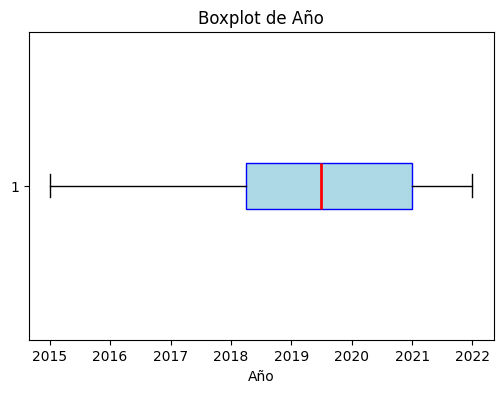

{'Q1': 2018.25, 'Q3': 2021.0, 'IQR': 2.75, 'limite_inferior': 2014.125, 'limite_superior': 2025.125}
Las dimensiones del nuevo dataframe es :(10, 9)
Aplicando la función de outlier para la columna Cantidad_Migrantes


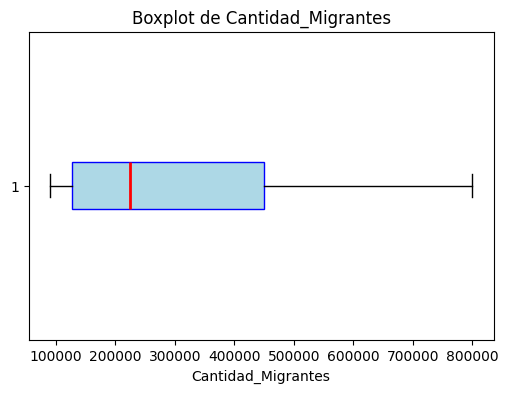

{'Q1': 127500.0, 'Q3': 450000.0, 'IQR': 322500.0, 'limite_inferior': -356250.0, 'limite_superior': 933750.0}
Las dimensiones del nuevo dataframe es :(10, 9)
Aplicando la función de outlier para la columna PIB_Origen


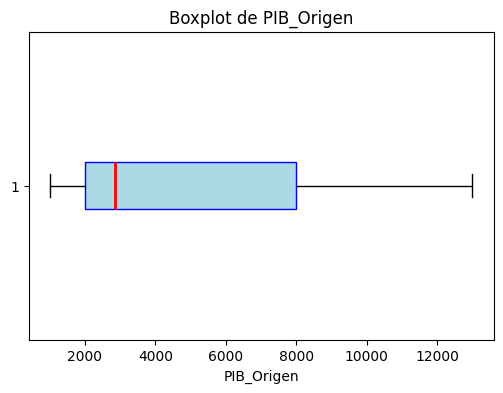

{'Q1': 2000.0, 'Q3': 8000.0, 'IQR': 6000.0, 'limite_inferior': -7000.0, 'limite_superior': 17000.0}
Las dimensiones del nuevo dataframe es :(10, 9)
Aplicando la función de outlier para la columna PIB_Destino


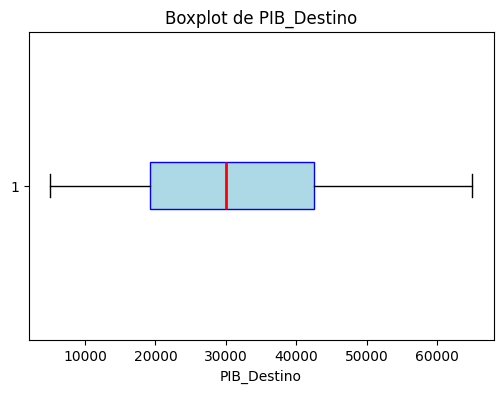

{'Q1': 19250.0, 'Q3': 42500.0, 'IQR': 23250.0, 'limite_inferior': -15625.0, 'limite_superior': 77375.0}
Las dimensiones del nuevo dataframe es :(10, 9)
Aplicando la función de outlier para la columna IDH_Origen


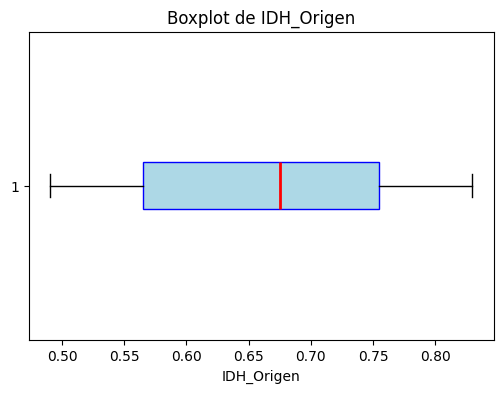

{'Q1': 0.5650000000000001, 'Q3': 0.755, 'IQR': 0.18999999999999995, 'limite_inferior': 0.28000000000000014, 'limite_superior': 1.04}
Las dimensiones del nuevo dataframe es :(10, 9)
Aplicando la función de outlier para la columna IDH_Destino


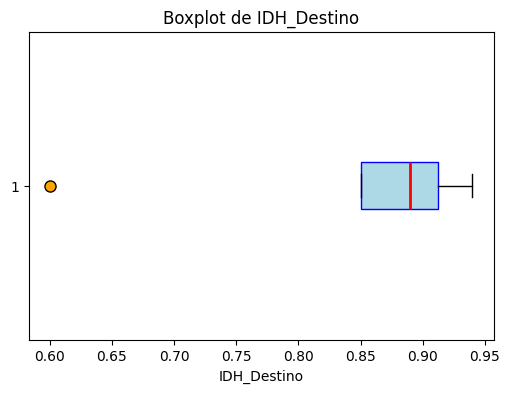

{'Q1': 0.85, 'Q3': 0.9125000000000001, 'IQR': 0.06250000000000011, 'limite_inferior': 0.7562499999999999, 'limite_superior': 1.0062500000000003}
Las dimensiones del nuevo dataframe es :(9, 9)


In [19]:
# Seleccionar solo columnas numéricas
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns
print(columnas_numericas)
for col in columnas_numericas:
    print(f"Aplicando la función de outlier para la columna {col}")
    detectar_outliers_iqr(df,col)


In [20]:
# Cambio de nombre en la columna "razon_migracion"
print(df['Razon_Migracion'])
df['Razon_Migracion'] = df['Razon_Migracion'].str.replace("Conflicto", "Guerra", regex=False)
df['Razon_Migracion'] = df['Razon_Migracion'].str.replace("Económica", "Trabajo", regex=False)
print(df['Razon_Migracion'])


0     Económica      
1     Conflicto      
2     Económica      
3     Educativa      
4     Económica      
5     Conflicto      
6     Conflicto      
7     Económica      
8     Económica      
9     Económica      
Name: Razon_Migracion, dtype: object
0       Trabajo      
1        Guerra      
2       Trabajo      
3     Educativa      
4       Trabajo      
5        Guerra      
6        Guerra      
7       Trabajo      
8       Trabajo      
9       Trabajo      
Name: Razon_Migracion, dtype: object


## 3. Agrupamiento y Sumarización de Datos (2 puntos)
- Agrupa los datos por `Razon_Migracion` y calcula la **suma total de migrantes** para cada categoría.  
- Obtén la **media** del IDH de los países de origen por cada tipo de migración.  
- Ordena el DataFrame de **mayor a menor** cantidad de migrantes.


## 4. Filtros y Selección de Datos (2 puntos)
- Filtra y muestra solo las migraciones por **conflicto**.  
- Selecciona y muestra las filas donde el **IDH del país de destino sea mayor a 0.90**.  
- Crea una nueva columna `Diferencia_IDH` que calcule la diferencia de IDH entre país de origen y destino.


## 5. Exportación de Datos (1 punto)
- Guarda el DataFrame final en un archivo CSV llamado `Migracion_Limpio.csv`, **sin índice**.


## INSTRUCCIONES ADICIONALES
- **Puntos totales = 10**.  
- Descarga el material complementario `migracion.csv`.  
- Comprime el archivo completo en formato `.zip` o `.rar`.  
- Sube el archivo a la plataforma.
